In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Image Restoration Lab

# 1. Background: Image Restoration

Image restoration aims to recover an estimate of the original image from a degraded observation.

A common degradation model is:

$$
g(x,y) = f(x,y) + \eta(x,y)
$$

where:

- $$f(x,y):$$ original image
- $$g(x,y):$$ observed noisy image
- $$\eta(x,y):$$ additive noise

For some systems, degradation may also include blur:

$$
g(x,y) = h(x,y) * f(x,y) + \eta(x,y)
$$

where:

- $$h(x,y)$$ is the degradation function or point spread function
- $$*$$ denotes convolution

In this lab, the focus is on **noise corruption** and **spatial-domain restoration filters**.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/content/drive/MyDrive/Recent Codes/images.jpg', 0)


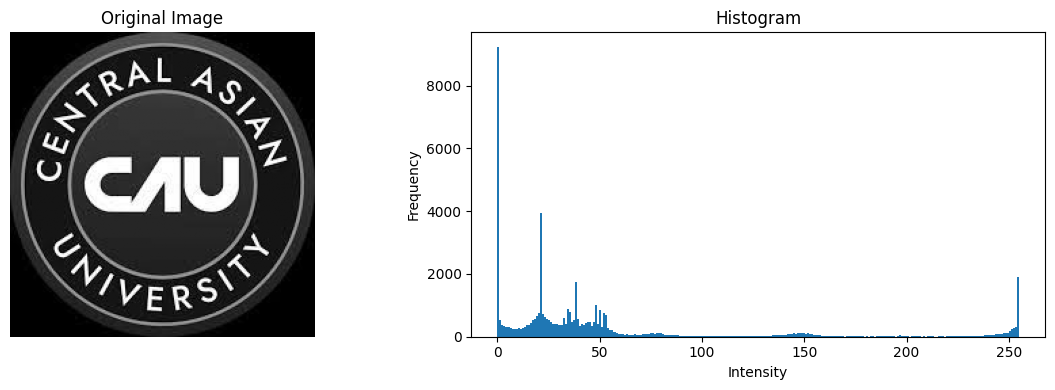

In [ ]:
# Show image and histogram
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(image.ravel(), bins=256, range=(0, 255))
plt.title("Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
def show_image_hist(image, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.hist(image.ravel(), bins=256, range=(0, 255))
    plt.title("Histogram")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# 2. Noise Models

A noise model describes how random intensity fluctuations affect an image.  
Different types of noise arise from different physical processes:

- sensor electronics
- thermal fluctuation
- photon counting
- transmission errors
- quantization and acquisition instability



In [ ]:
# ----------------------------
# Noise generation functions
# ----------------------------

def add_gaussian_noise(image, mean=0, std=20):
    noise = np.random.normal(mean, std, image.shape)
    return np.clip(image + noise, 0, 255)

def add_rayleigh_noise(image, scale=20):
    noise = np.random.rayleigh(scale, image.shape)
    return np.clip(image + noise, 0, 255)

def add_exponential_noise(image, scale=20):
    noise = np.random.exponential(scale, image.shape)
    return np.clip(image + noise, 0, 255)

def add_uniform_noise(image, low=-20, high=20):
    noise = np.random.uniform(low, high, image.shape)
    return np.clip(image + noise, 0, 255)

def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = image.copy()
    total = image.size

    num_salt = int(total * salt_prob)
    coords_salt = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords_salt[0], coords_salt[1]] = 255

    num_pepper = int(total * pepper_prob)
    coords_pepper = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords_pepper[0], coords_pepper[1]] = 0
    return noisy

## 2.1 Gaussian Noise

### Definition
Gaussian noise is the most common statistical noise model in image processing.  
Its values follow a **normal distribution**.

### Probability density function
$$
p(z)=\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(z-\mu)^2}{2\sigma^2}\right)
$$

where:
- $$\mu$$: mean
- $$\sigma$$: standard deviation

### Functional meaning
- the **mean** shifts brightness bias
- the **standard deviation** controls noise strength
- noise is spread across many pixels with continuous values

### Effect on image
- produces grain-like fluctuations
- preserves overall structure at low variance
- increasingly obscures edges and textures as \(\sigma\) grows

### Typical applications / occurrence
- sensor readout noise
- thermal electronic noise
- acquisition systems where many small independent disturbances add together

### Advantages of modeling it
- analytically convenient
- widely used as a benchmark
- many restoration methods are designed assuming Gaussian noise

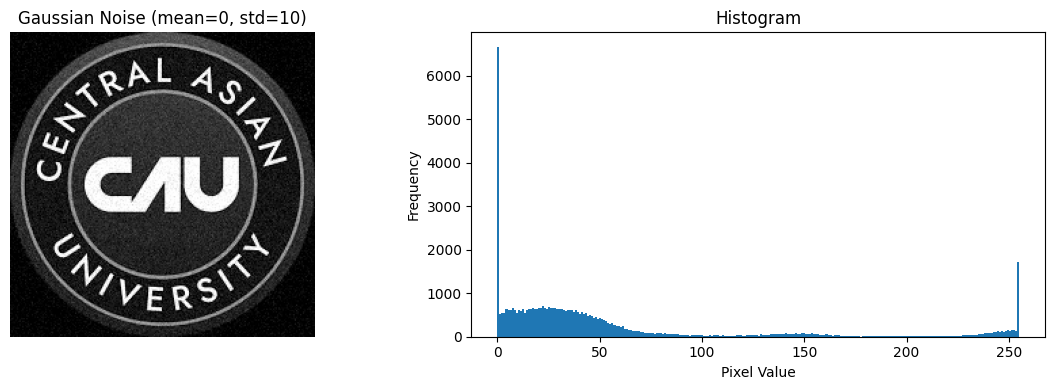

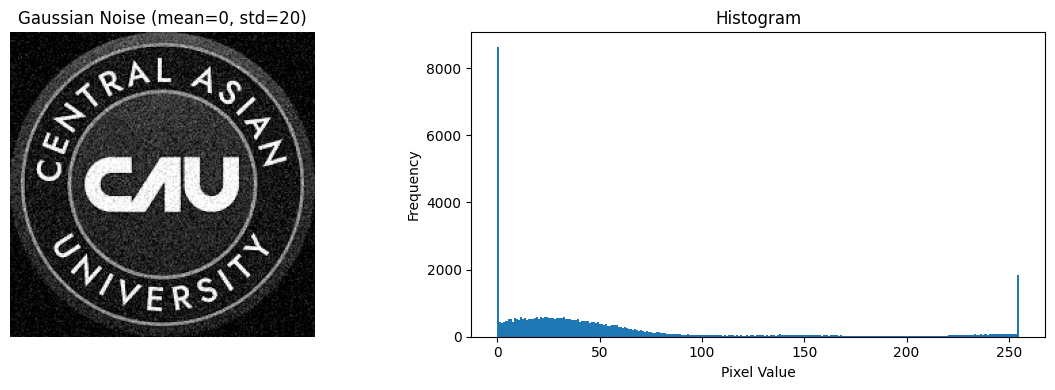

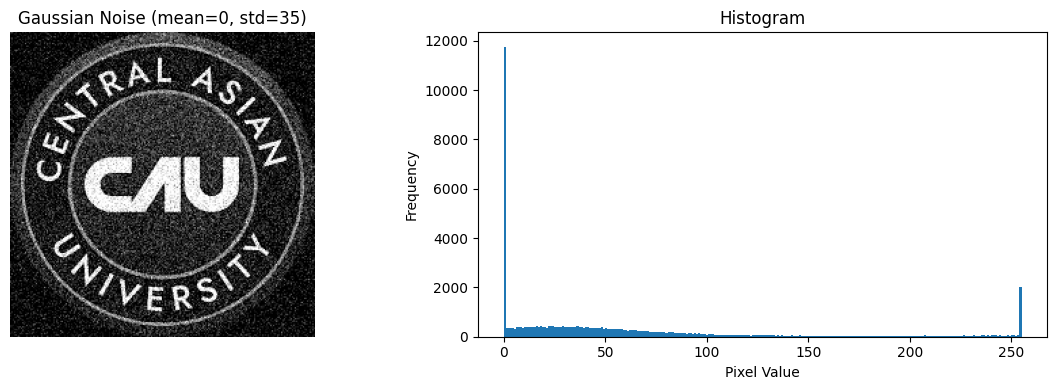

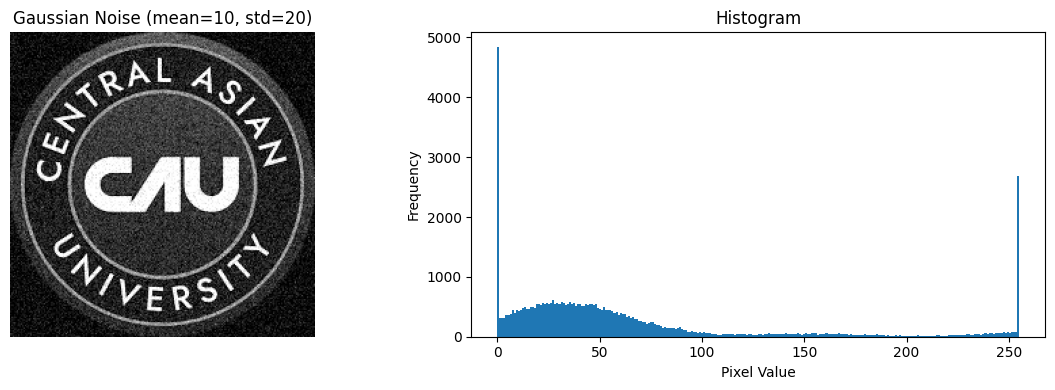

In [ ]:
gaussian_examples = [(0, 10), (0, 20), (0, 35), (10, 20)]

for mean, std in gaussian_examples:
    noisy = add_gaussian_noise(image, mean=mean, std=std)
    show_image_hist(noisy, f"Gaussian Noise (mean={mean}, std={std})")

## 2.2 Rayleigh Noise

### Definition
Rayleigh noise follows the Rayleigh distribution and is often used when the observed quantity is the magnitude of two orthogonal Gaussian components.

### Probability density function
$$
p(z)=
\begin{cases}
\frac{z-a}{b}\exp\left(-\frac{(z-a)^2}{2b}\right), & z \ge a \\
0, & z < a
\end{cases}
$$

In simulation form, a scale parameter is commonly used.

### Functional meaning
- values are nonnegative
- tends to skew the histogram toward brighter values
- noise is asymmetric compared with zero-mean Gaussian noise

### Effect on image
- introduces positively biased intensity fluctuations
- causes brightening and uneven grain structure
- may distort low-contrast areas

### Typical applications / occurrence
- radar and range imaging contexts
- magnitude-domain measurements
- some coherent imaging scenarios

### Advantages of studying it
- useful for understanding skewed noise
- demonstrates that not all noise is symmetric around zero

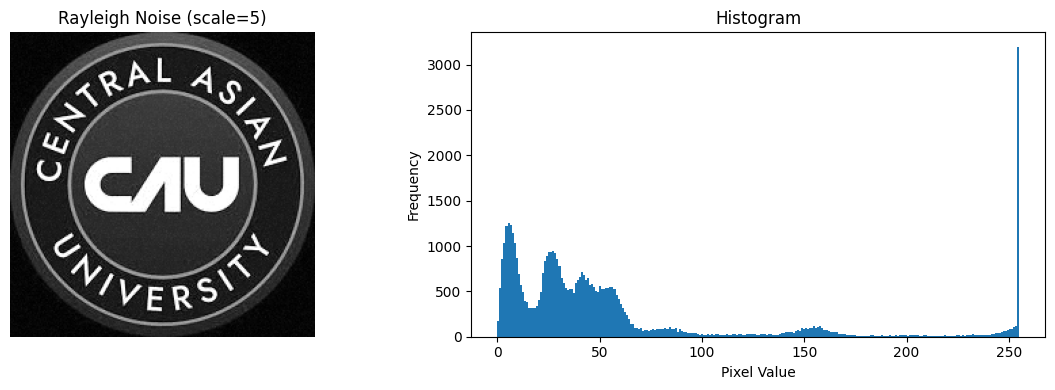

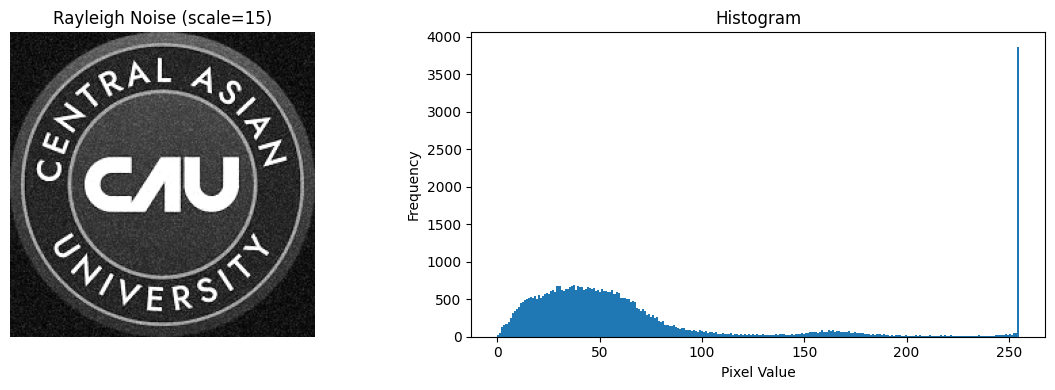

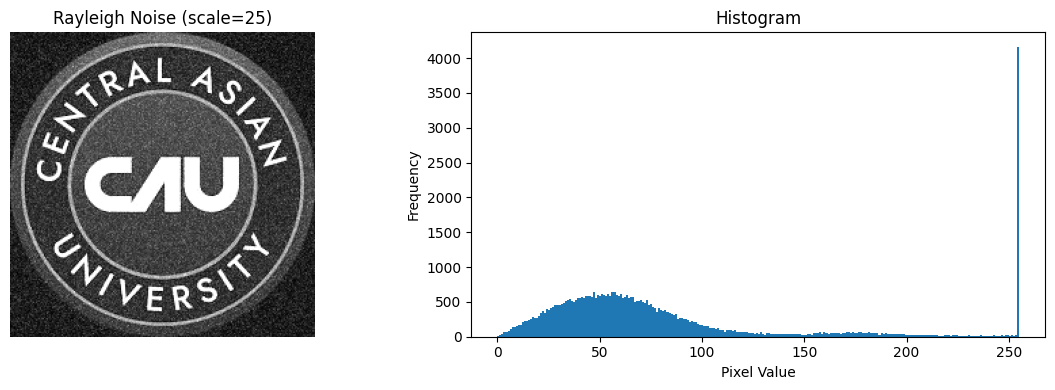

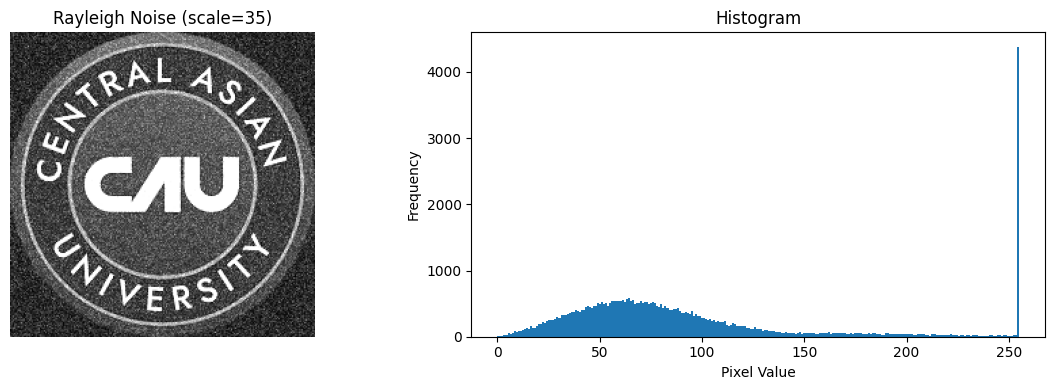

In [ ]:
rayleigh_scales = [5, 15, 25, 35]

for scale in rayleigh_scales:
    noisy = add_rayleigh_noise(image, scale=scale)
    show_image_hist(noisy, f"Rayleigh Noise (scale={scale})")

## 2.3 Exponential Noise

### Definition
Exponential noise is a one-sided random process often used to represent waiting-time or decay-related random variables.

### Probability density function
$$
p(z)=
\begin{cases}
\lambda e^{-\lambda z}, & z \ge 0 \\
0, & z < 0
\end{cases}
$$

If scale \(= 1/\lambda\), then larger scale means stronger noise.

### Functional meaning
- only adds positive random values
- tends to push intensities upward
- introduces strong asymmetry in the histogram

### Effect on image
- visible positive intensity bias
- image can look washed or unevenly brightened
- weak regions may be overwhelmed quickly

### Typical applications / occurrence
- stochastic event modeling
- some acquisition and transmission models
- educational comparison against Gaussian and uniform noise

### Advantages of studying it
- helps interpret skewed additive noise
- useful contrast with symmetric distributions

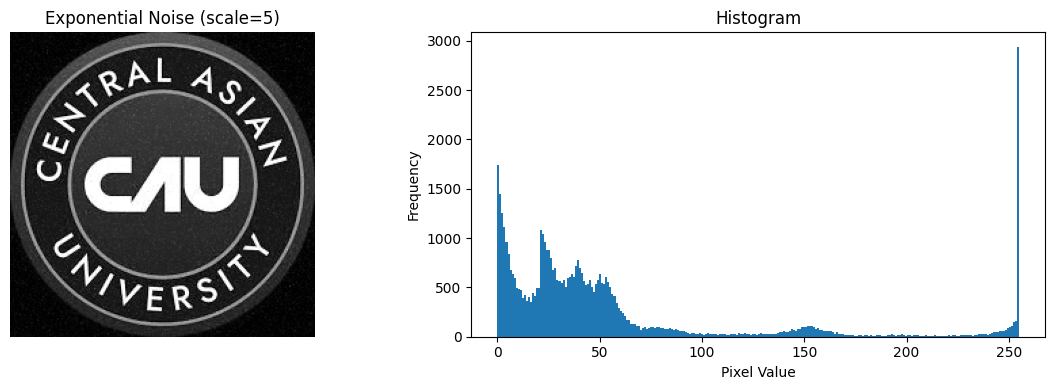

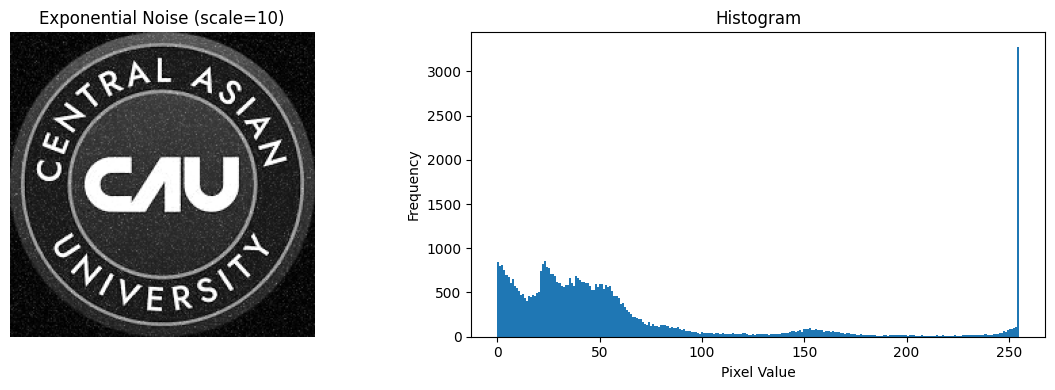

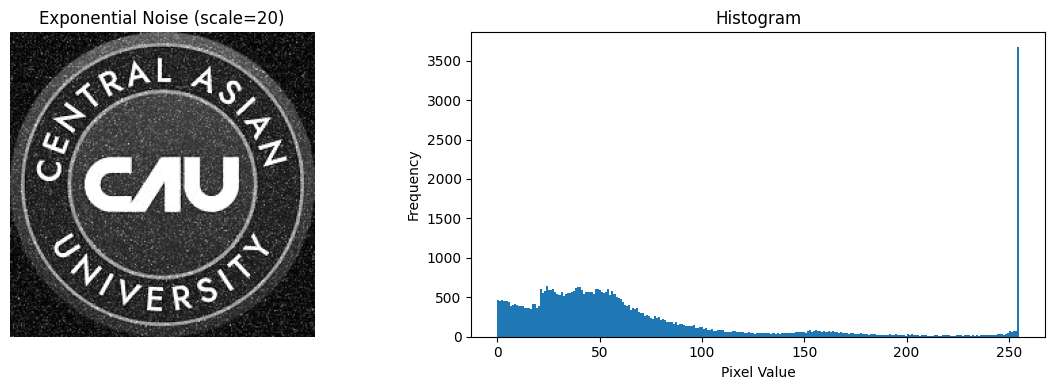

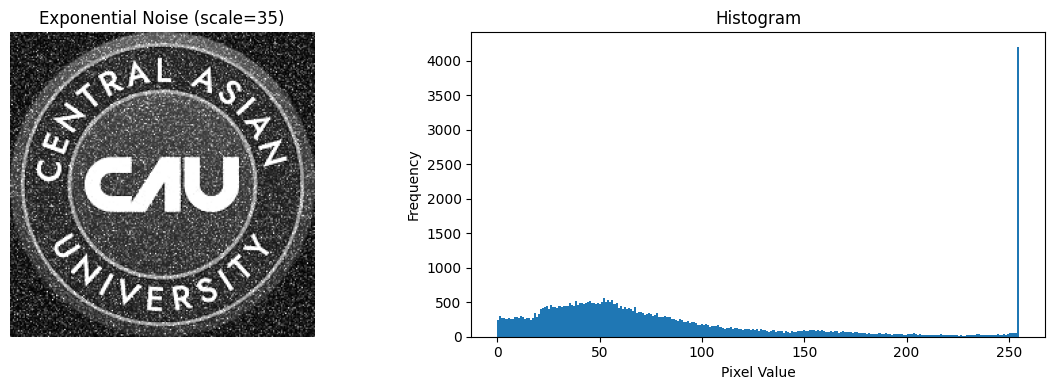

In [ ]:
exp_scales = [5, 10, 20, 35]

for scale in exp_scales:
    noisy = add_exponential_noise(image, scale=scale)
    show_image_hist(noisy, f"Exponential Noise (scale={scale})")

## 2.4 Uniform Noise

### Definition
Uniform noise assigns every value in a fixed interval the same probability.

### Probability density function
$$
p(z)=
\begin{cases}
\frac{1}{b-a}, & a \le z \le b \\
0, & \text{otherwise}
\end{cases}
$$

### Functional meaning
- every noise value between \(a\) and \(b\) is equally likely
- useful in quantization and bounded uncertainty modeling

### Effect on image
- produces moderate flat random variation
- less extreme than impulse noise
- histogram broadens in a bounded way

### Typical applications / occurrence
- quantization error models
- bounded simulation noise
- synthetic testing and numerical experiments

### Advantages of studying it
- easy to understand
- bounded support makes it predictable
- useful baseline for simulation

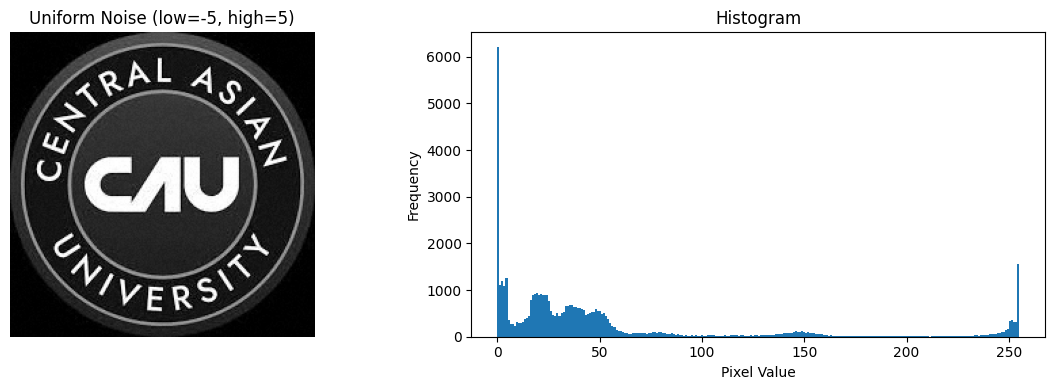

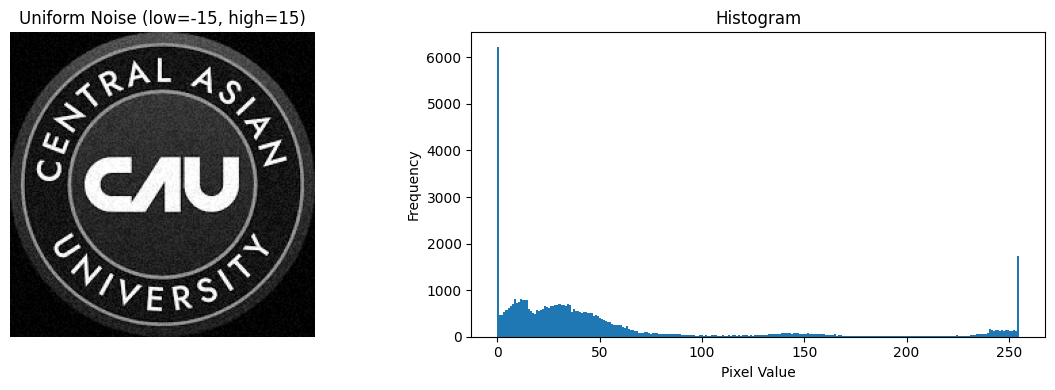

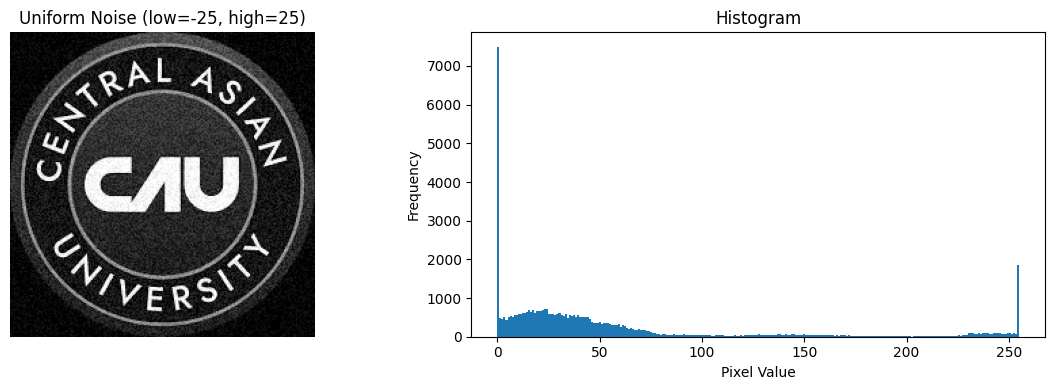

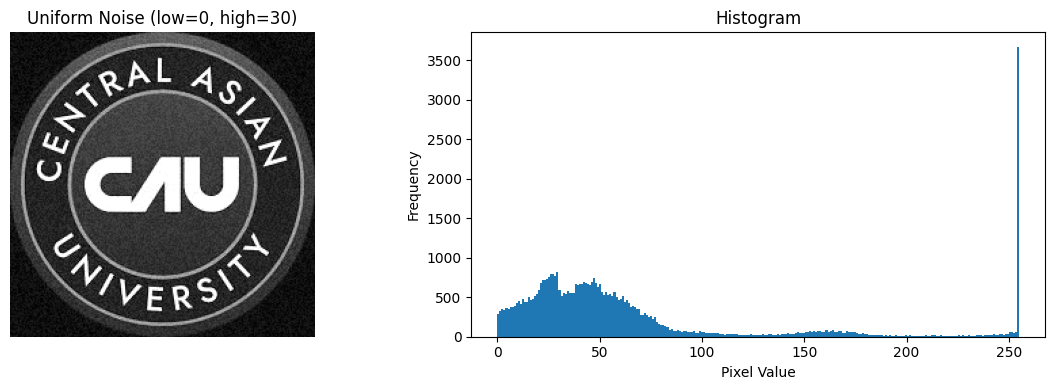

In [ ]:
uniform_ranges = [(-5, 5), (-15, 15), (-25, 25), (0, 30)]

for low, high in uniform_ranges:
    noisy = add_uniform_noise(image, low=low, high=high)
    show_image_hist(noisy, f"Uniform Noise (low={low}, high={high})")

## 2.5 Salt-and-Pepper Noise

### Definition
Salt-and-pepper noise is an **impulse noise** model where some pixels are replaced by the minimum or maximum gray level.

$$
g(x,y)=
\begin{cases}
0, & \text{with probability } P_p \\
255, & \text{with probability } P_s \\
f(x,y), & \text{with probability } 1-P_s-P_p
\end{cases}
$$

where:
- \(P_s\): probability of salt impulses (white pixels)
- \(P_p\): probability of pepper impulses (black pixels)

### Functional meaning
- corruption is sparse but severe
- affected pixels are replaced completely
- values are not slightly perturbed; they become outliers

### Effect on image
- black and white speckles
- edge information may survive better than under strong Gaussian blur
- isolated impulses are visually obvious

### Typical applications / occurrence
- faulty sensors
- bit errors during transmission
- analog-to-digital conversion errors
- dead pixels and switching disturbances

### Advantages of studying it
- illustrates the failure of simple averaging filters
- motivates nonlinear filtering, especially the median filter

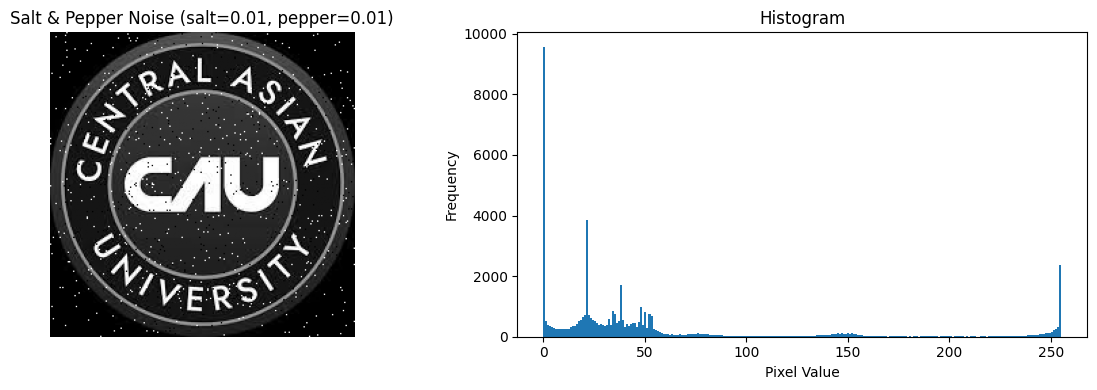

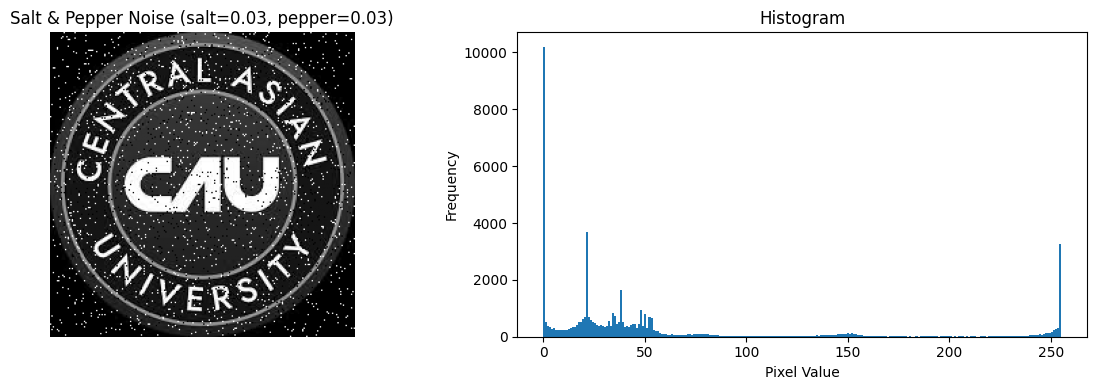

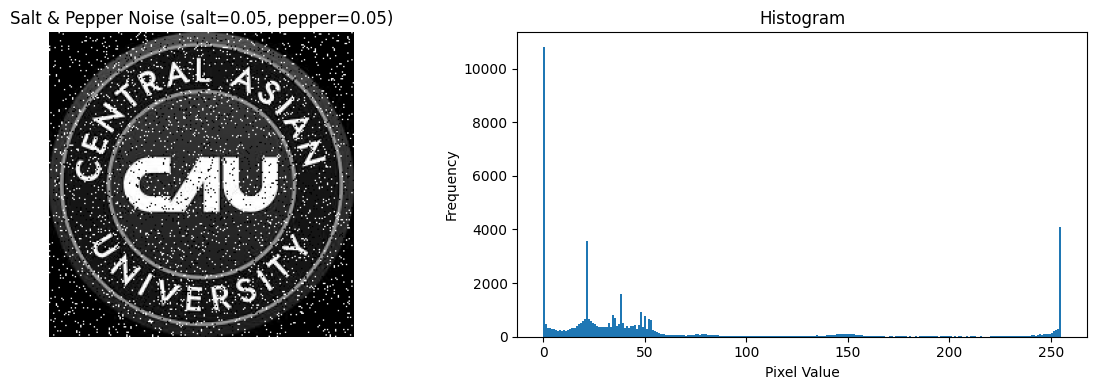

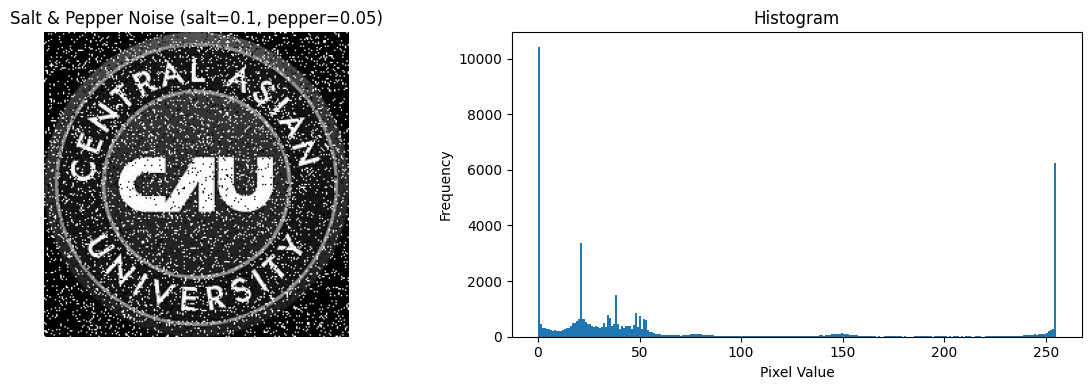

In [ ]:
sp_examples = [(0.01, 0.01), (0.03, 0.03), (0.05, 0.05), (0.10, 0.05)]

for salt_prob, pepper_prob in sp_examples:
    noisy = add_salt_pepper_noise(image, salt_prob=salt_prob, pepper_prob=pepper_prob)
    show_image_hist(noisy, f"Salt & Pepper Noise (salt={salt_prob}, pepper={pepper_prob})")

# 3. Spatial Restoration Filters

A spatial filter replaces each pixel by a function of the values in a neighborhood.

For a neighborhood $$S_{xy}$$ of size $$m \times n$$, the restored value is:

$$
\hat{f}(x,y)=T\{g(s,t)\}, \quad (s,t)\in S_{xy}
$$

The operator \(T\) may be:
- **linear**, such as averaging via convolution
- **nonlinear**, such as median, min, max, harmonic, or contraharmonic operations

This section separates each filter by:
- equation
- kernel / mask / matrix when applicable
- effect
- functionality
- application
- advantages

In [ ]:
# --------------------------------
# Restoration filter definitions
# --------------------------------

def arithmetic_mean_filter(image, k=3):
    kernel = np.ones((k, k), dtype=np.float32) / (k * k)
    return cv2.filter2D(image, -1, kernel, borderType=cv2.BORDER_REPLICATE)

def median_filter(image, k=3):
    pad = k // 2
    padded = np.pad(image, pad, mode="edge")
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+k, j:j+k]
            result[i, j] = np.median(patch)
    return result

def min_filter(image, k=3):
    pad = k // 2
    padded = np.pad(image, pad, mode="edge")
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            result[i, j] = np.min(padded[i:i+k, j:j+k])
    return result

def max_filter(image, k=3):
    pad = k // 2
    padded = np.pad(image, pad, mode="edge")
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            result[i, j] = np.max(padded[i:i+k, j:j+k])
    return result

def midpoint_filter(image, k=3):
    return 0.5 * (min_filter(image, k) + max_filter(image, k))

def geometric_mean_filter(image, k=3):
    pad = k // 2
    padded = np.pad(image + 1, pad, mode="edge")  # +1 avoids log(0)
    result = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+k, j:j+k]
            result[i, j] = np.exp(np.mean(np.log(patch)))
    return result - 1

def harmonic_mean_filter(image, k=3):
    pad = k // 2
    padded = np.pad(image + 1, pad, mode="edge")
    result = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+k, j:j+k]
            result[i, j] = (k * k) / np.sum(1.0 / patch)
    return result - 1

def contraharmonic_mean_filter(image, k=3, Q=1.5):
    pad = k // 2
    padded = np.pad(image + 1, pad, mode="edge")
    result = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+k, j:j+k]
            num = np.sum(patch ** (Q + 1))
            den = np.sum(patch ** Q)
            result[i, j] = num / den if den != 0 else 0
    return result - 1

def alpha_trimmed_mean_filter(image, k=3, d=2):
    pad = k // 2
    padded = np.pad(image, pad, mode="edge")
    result = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = np.sort(padded[i:i+k, j:j+k].flatten())
            trimmed = patch[d // 2 : len(patch) - d // 2]
            result[i, j] = np.mean(trimmed)
    return result

## 3.1 Arithmetic Mean Filter

### Equation
$$
\hat{f}(x,y)=\frac{1}{mn}\sum_{(s,t)\in S_{xy}} g(s,t)
$$

### Kernel / mask / matrix
For a $$3\times3$$ neighborhood:

$$
\frac{1}{9}
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1
\end{bmatrix}
$$

### Functionality
- computes the average of the local neighborhood
- smooths small fluctuations
- equivalent to convolution with a box kernel

### Effect on image
- reduces random variation
- blurs edges and fine structures
- can smear impulses into neighbors

### Applications
- mild Gaussian-like noise suppression
- simple low-pass smoothing
- baseline restoration method

### Advantages
- simple
- fast
- easy to implement
- works reasonably for small zero-mean random noise

In [ ]:
mean_kernel_3x3 = np.ones((3, 3), dtype=np.float32) / 9.0
mean_kernel_5x5 = np.ones((5, 5), dtype=np.float32) / 25.0

print("3x3 mean filter kernel:\n", mean_kernel_3x3)
print("\n5x5 mean filter kernel:\n", mean_kernel_5x5)

3x3 mean filter kernel:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

5x5 mean filter kernel:
 [[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


## 3.2 Median Filter

### Equation
$$
\hat{f}(x,y)=\operatorname{median}\{g(s,t)\}, \quad (s,t)\in S_{xy}
$$

### Kernel / matrix note
The median filter is **nonlinear**, so it does **not** have a fixed convolution kernel.  
Instead, it sorts neighborhood values and chooses the median.

Example $$3\times3$$ neighborhood:

$$
\begin{bmatrix}
10 & 12 & 255 \\
9  & 11 & 13 \\
8  & 10 & 12
\end{bmatrix}
$$

Sorted values:
$$
[8, 9, 10, 10, 11, 12, 12, 13, 255]
$$

Median:
\[
11
\]

### Functionality
- rejects isolated outliers
- preserves edges better than averaging in many cases
- especially effective for impulse noise

### Effect on image
- removes salt-and-pepper speckles
- less blur than arithmetic averaging
- can still soften tiny details if the window grows too large

### Applications
- impulse noise removal
- preprocessing before segmentation or edge detection
- robust denoising when outliers exist

### Advantages
- excellent for salt-and-pepper noise
- nonlinear robustness to extreme pixels
- good edge preservation relative to mean filtering

## 3.3 Min Filter

### Equation
$$
\hat{f}(x,y)=\min\{g(s,t)\}, \quad (s,t)\in S_{xy}
$$

### Kernel / matrix note
This is a **nonlinear order-statistics filter**, so there is no fixed convolution matrix.

### Functionality
- replaces the center pixel with the minimum in the neighborhood

### Effect on image
- removes bright impulses (salt noise)
- darkens the image
- may shrink bright objects

### Applications
- suppressing positive spikes
- morphology-like darkening effects

### Advantages
- useful against salt noise
- simple order-statistics operation

## 3.4 Max Filter

### Equation
$$
\hat{f}(x,y)=\max\{g(s,t)\}, \quad (s,t)\in S_{xy}
$$

### Kernel / matrix note
Also **nonlinear**, with no fixed linear convolution kernel.

### Functionality
- replaces the center pixel with the maximum in the neighborhood

### Effect on image
- removes dark impulses (pepper noise)
- brightens the image
- may enlarge bright regions

### Applications
- suppressing pepper noise
- morphology-like brightening effects

### Advantages
- useful for dark impulse removal
- very simple local operator

## 3.5 Midpoint Filter

### Equation
$$
\hat{f}(x,y)=\frac{1}{2}\left[\max\{g(s,t)\}+\min\{g(s,t)\}\right]
$$

### Functionality
- averages the local extreme values
- useful for uniformly distributed random noise

### Effect on image
- can reduce bounded noise
- smoother than min or max alone
- less robust than median for impulse corruption

### Applications
- uniform noise scenarios
- bounded random fluctuation reduction

### Advantages
- simple
- intuitive
- useful when local extrema represent the noise range

## 3.6 Geometric Mean Filter

### Equation
$$
\hat{f}(x,y)=\left(\prod_{(s,t)\in S_{xy}} g(s,t)\right)^{\frac{1}{mn}}
$$

Equivalent log-domain form:

$$
\hat{f}(x,y)=\exp\left(
\frac{1}{mn}\sum_{(s,t)\in S_{xy}} \ln g(s,t)
\right)
$$

### Functionality
- multiplies neighborhood values and takes the \(mn\)-th root
- behaves differently from arithmetic averaging
- tends to preserve detail slightly better than the arithmetic mean in some cases

### Effect on image
- smooths noise
- avoids excessive influence of large values
- requires care around zero values

### Applications
- Gaussian-like and multiplicative-noise style experiments
- educational comparison with arithmetic mean

### Advantages
- less blur than arithmetic mean in some settings
- mathematically useful for log-domain analysis

## 3.7 Harmonic Mean Filter

### Equation
$$
\hat{f}(x,y)=\frac{mn}{\sum_{(s,t)\in S_{xy}}\frac{1}{g(s,t)}}
$$

### Functionality
- emphasizes smaller values differently than arithmetic averaging
- can work well for certain non-Gaussian noise conditions

### Effect on image
- good for reducing salt noise in some cases
- not suitable when pepper noise dominates because zeros are problematic

### Applications
- positive random noise scenarios
- comparison against arithmetic and geometric means

### Advantages
- useful alternative to standard averaging
- can outperform arithmetic mean in specific distributions

## 3.8 Contraharmonic Mean Filter

### Equation
$$
\hat{f}(x,y)=
\frac{\sum_{(s,t)\in S_{xy}} g(s,t)^{Q+1}}
{\sum_{(s,t)\in S_{xy}} g(s,t)^Q}
$$

### Role of \(Q\)
- \(Q > 0\): better for **pepper noise**
- \(Q < 0\): better for **salt noise**

### Functionality
- generalizes several mean filters
- allows directional preference against bright or dark impulses depending on \(Q\)

### Effect on image
- can be highly effective when the impulse type is known
- may fail if both salt and pepper are strong simultaneously

### Applications
- impulse-noise reduction when noise polarity is known
- advanced order-statistics restoration

### Advantages
- tunable behavior through \(Q\)
- more flexible than harmonic mean

## 3.9 Alpha-Trimmed Mean Filter

### Equation
Sort the \(mn\) neighborhood samples, remove the \(d/2\) lowest and \(d/2\) highest values, then average the remaining values:

$$
\hat{f}(x,y)=\frac{1}{mn-d}\sum_{r=d/2+1}^{mn-d/2} z_r
$$

where \(z_r\) are the sorted intensities.

### Functionality
- combines averaging with outlier rejection
- bridges the behavior of mean and median filtering

### Effect on image
- effective for mixed noise
- reduces influence of outliers
- can preserve detail better than plain averaging

### Applications
- images corrupted by both Gaussian-like noise and occasional impulses
- robust smoothing problems

### Advantages
- flexible compromise between mean and median
- suitable for mixed-noise conditions

# 4. Practical Demonstrations by Filter Type

In [ ]:
def to_uint8(img):
    return np.clip(img, 0, 255).astype(np.uint8)

In [ ]:
def show_three(original, noisy, restored, titles=("Original", "Noisy", "Restored")):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, img, t in zip(ax, [original, noisy, restored], titles):
        a.imshow(to_uint8(img), cmap="gray", vmin=0, vmax=255)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()

## 4.1 Mean Filter on Gaussian Noise

Because Gaussian noise is distributed across many pixels, local averaging often reduces its variance, though at the cost of edge blur.

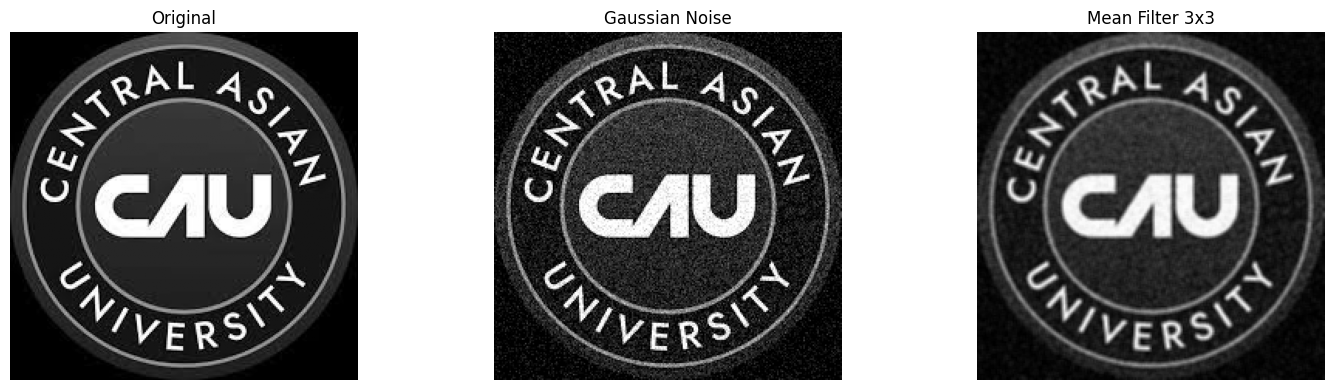

In [ ]:
gaussian_noisy = add_gaussian_noise(image, mean=0, std=20)
mean_restored = arithmetic_mean_filter(gaussian_noisy, k=3)
show_three(image, gaussian_noisy, mean_restored,
           ("Original", "Gaussian Noise", "Mean Filter 3x3"))

## 4.2 Median Filter on Salt-and-Pepper Noise

Median filtering is the standard choice for impulse noise because outlier pixels do not dominate the ordered neighborhood.

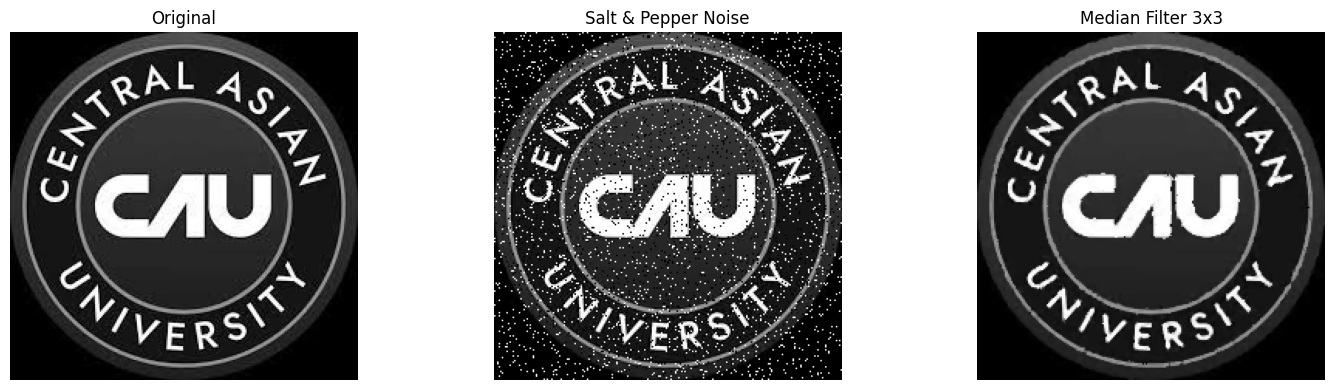

In [ ]:
sp_noisy = add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05)
median_restored = median_filter(sp_noisy, k=3)
show_three(image, sp_noisy, median_restored,
           ("Original", "Salt & Pepper Noise", "Median Filter 3x3"))

## 4.3 Min and Max Filters on Impulse Noise

- **Min filter** tends to suppress bright salt impulses.
- **Max filter** tends to suppress dark pepper impulses.

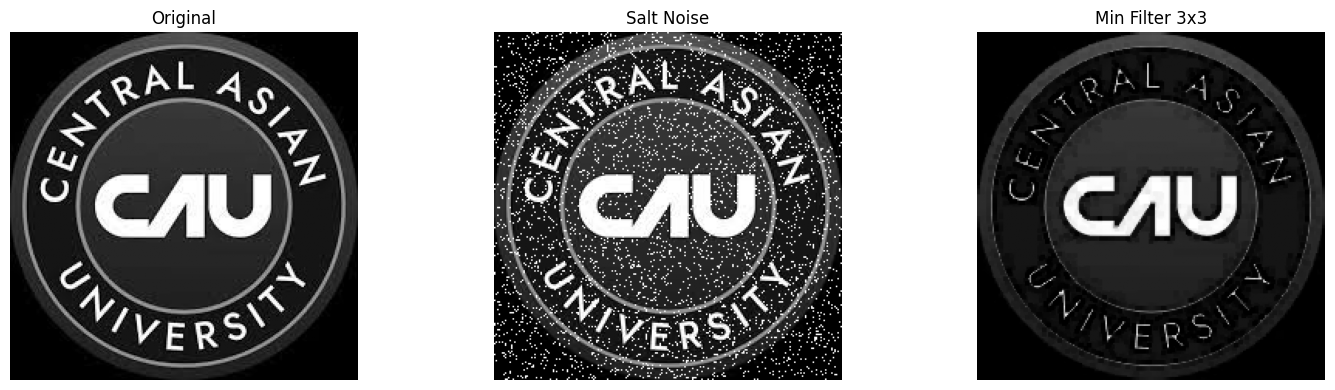

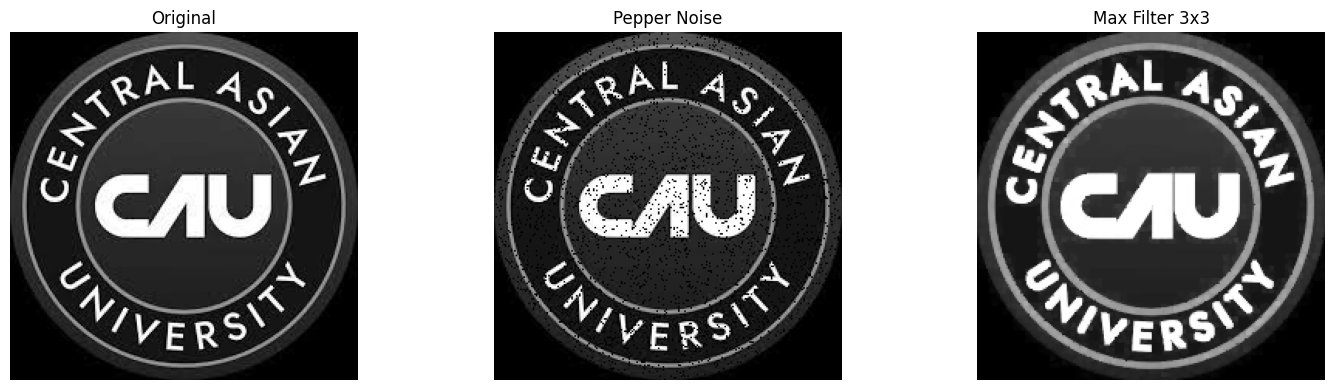

In [ ]:
salt_heavy = add_salt_pepper_noise(image, salt_prob=0.08, pepper_prob=0.00)
pepper_heavy = add_salt_pepper_noise(image, salt_prob=0.00, pepper_prob=0.08)

min_restored = min_filter(salt_heavy, k=3)
max_restored = max_filter(pepper_heavy, k=3)

show_three(image, salt_heavy, min_restored,
           ("Original", "Salt Noise", "Min Filter 3x3"))

show_three(image, pepper_heavy, max_restored,
           ("Original", "Pepper Noise", "Max Filter 3x3"))

## 4.4 Midpoint Filter on Uniform Noise

The midpoint filter uses local extrema, making it useful when noise values are bounded.

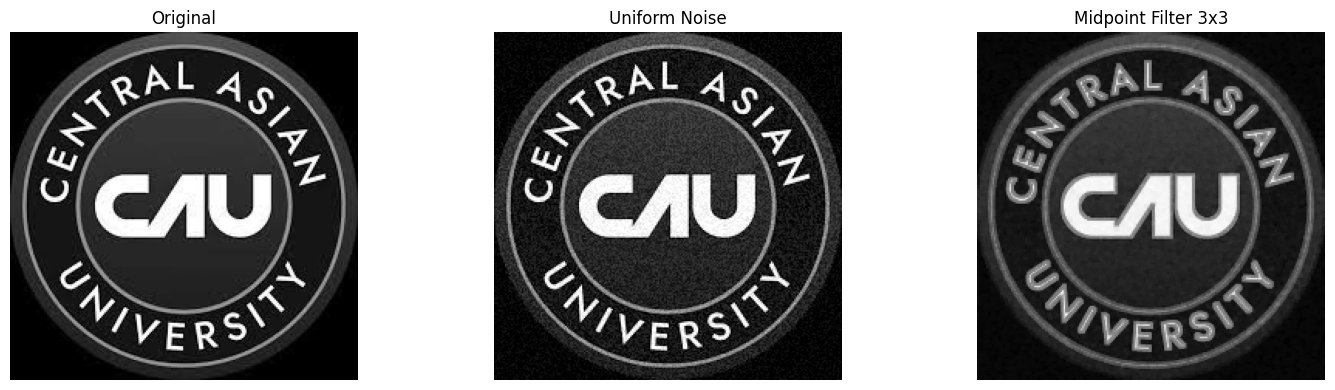

In [ ]:
uniform_noisy = add_uniform_noise(image, low=-20, high=20)
midpoint_restored = midpoint_filter(uniform_noisy, k=3)

show_three(image, uniform_noisy, midpoint_restored,
           ("Original", "Uniform Noise", "Midpoint Filter 3x3"))

## 4.5 Geometric and Harmonic Mean Filters

These filters are alternatives to arithmetic averaging and are useful for comparing the effect of different local means.

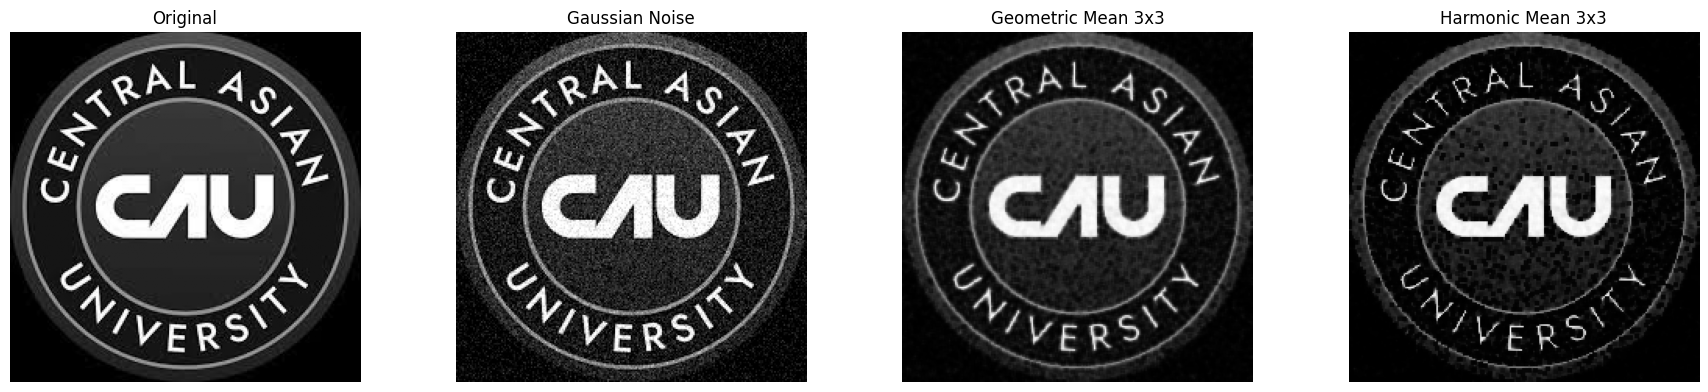

In [ ]:
gaussian_noisy_2 = add_gaussian_noise(image, mean=0, std=20)
geo_restored = geometric_mean_filter(gaussian_noisy_2, k=3)
harm_restored = harmonic_mean_filter(gaussian_noisy_2, k=3)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
items = [
    (image, "Original"),
    (gaussian_noisy_2, "Gaussian Noise"),
    (geo_restored, "Geometric Mean 3x3"),
    (harm_restored, "Harmonic Mean 3x3"),
]
for a, (img, title) in zip(ax, items):
    a.imshow(to_uint8(img), cmap="gray", vmin=0, vmax=255)
    a.set_title(title)
    a.axis("off")
plt.tight_layout()
plt.show()

## 4.6 Contraharmonic Mean Filter

The choice of \(Q\) changes which impulses are suppressed:
- \(Q > 0\): better for pepper noise
- \(Q < 0\): better for salt noise

/tmp/ipykernel_1431/3575312043.py:67: RuntimeWarning: divide by zero encountered in power
  num = np.sum(patch ** (Q + 1))
/tmp/ipykernel_1431/3575312043.py:68: RuntimeWarning: divide by zero encountered in power
  den = np.sum(patch ** Q)
/tmp/ipykernel_1431/3575312043.py:69: RuntimeWarning: invalid value encountered in scalar divide
  result[i, j] = num / den if den != 0 else 0


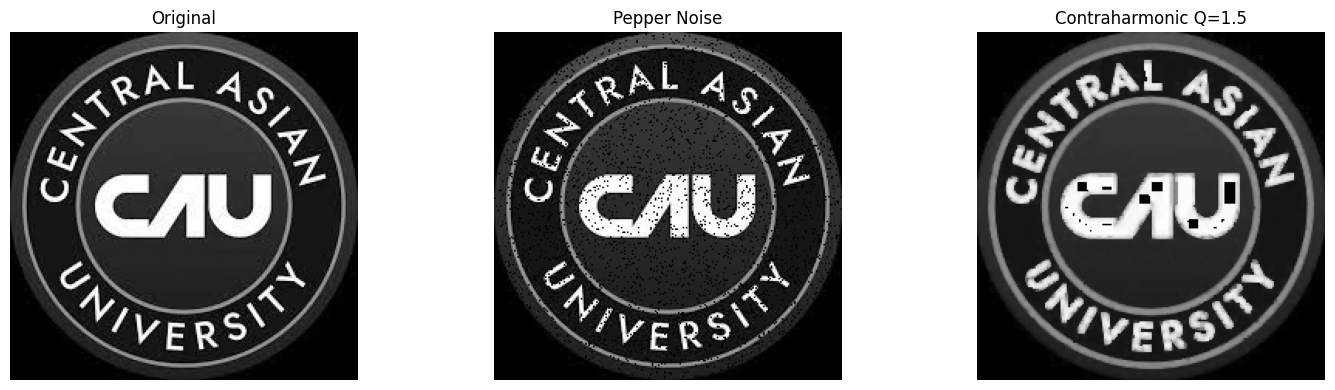

/tmp/ipykernel_1431/3764597156.py:2: RuntimeWarning: invalid value encountered in cast
  return np.clip(img, 0, 255).astype(np.uint8)


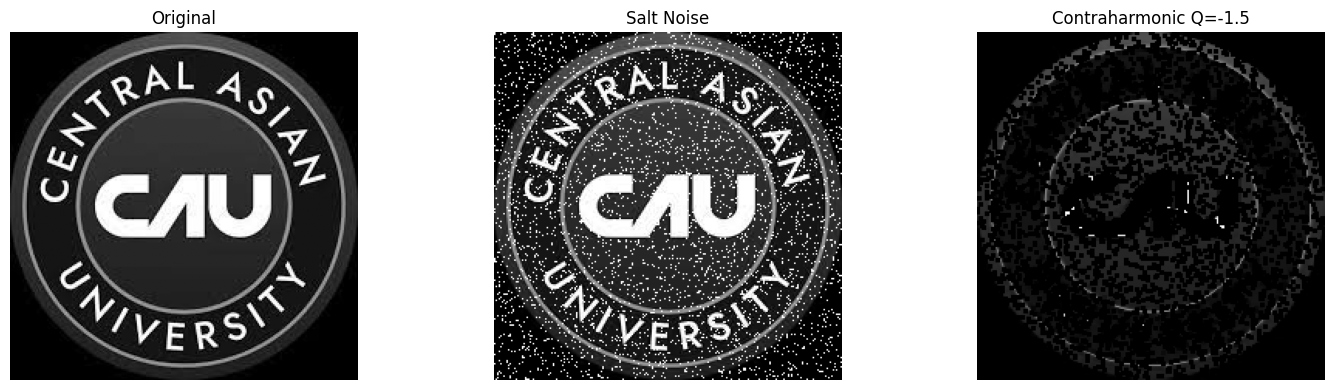

In [ ]:
pepper_noisy = add_salt_pepper_noise(image, salt_prob=0.00, pepper_prob=0.08)
salt_noisy = add_salt_pepper_noise(image, salt_prob=0.08, pepper_prob=0.00)

contra_pepper = contraharmonic_mean_filter(pepper_noisy, k=3, Q=1.5)
contra_salt = contraharmonic_mean_filter(salt_noisy, k=3, Q=-1.5)

show_three(image, pepper_noisy, contra_pepper,
           ("Original", "Pepper Noise", "Contraharmonic Q=1.5"))

show_three(image, salt_noisy, contra_salt,
           ("Original", "Salt Noise", "Contraharmonic Q=-1.5"))

## 4.7 Alpha-Trimmed Mean Filter

This filter removes a few extreme values from each neighborhood before averaging the rest.

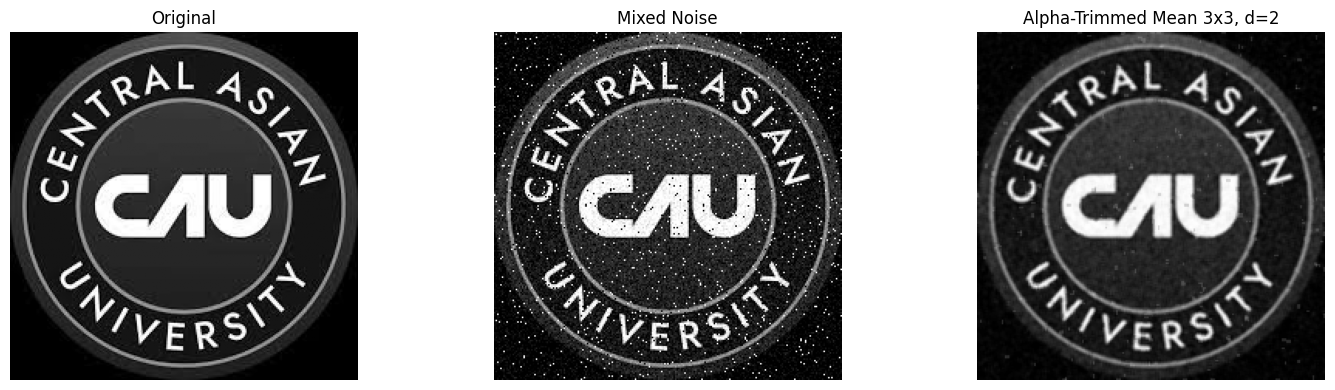

In [ ]:
mixed_noisy = add_gaussian_noise(image, 0, 15)
mixed_noisy = add_salt_pepper_noise(mixed_noisy, salt_prob=0.02, pepper_prob=0.02)

alpha_restored = alpha_trimmed_mean_filter(mixed_noisy, k=3, d=2)

show_three(image, mixed_noisy, alpha_restored,
           ("Original", "Mixed Noise", "Alpha-Trimmed Mean 3x3, d=2"))

# 5. Quantitative Evaluation

Two common metrics are used here.

## Mean Squared Error (MSE)
$$
MSE = \frac{1}{MN}\sum_{x=0}^{M-1}\sum_{y=0}^{N-1}
\left[f(x,y)-\hat{f}(x,y)\right]^2
$$

Lower MSE indicates a closer reconstruction.

## Peak Signal-to-Noise Ratio (PSNR)
$$
PSNR = 10 \log_{10}\left(\frac{255^2}{MSE}\right)
$$

Higher PSNR generally indicates better restoration.

In [ ]:
def mse(original, restored):
    original = original.astype(np.float32)
    restored = restored.astype(np.float32)
    return np.mean((original - restored) ** 2)

def psnr(original, restored):
    m = mse(original, restored)
    if m == 0:
        return float("inf")
    return 10 * np.log10((255 ** 2) / m)

## 5.1 Compare Filters on Gaussian Noise

In [ ]:
gaussian_noisy = add_gaussian_noise(image, mean=0, std=20)

gaussian_results = {
    "Mean 3x3": arithmetic_mean_filter(gaussian_noisy, 3),
    "Median 3x3": median_filter(gaussian_noisy, 3),
    "Geometric 3x3": geometric_mean_filter(gaussian_noisy, 3),
    "Harmonic 3x3": harmonic_mean_filter(gaussian_noisy, 3),
    "Alpha-Trimmed 3x3 d=2": alpha_trimmed_mean_filter(gaussian_noisy, 3, 2),
}

gaussian_scores = []
for name, restored in gaussian_results.items():
    gaussian_scores.append((name, mse(image, restored), psnr(image, restored)))

for name, m, p in gaussian_scores:
    print(f"{name:25s}  MSE = {m:10.2f}   PSNR = {p:8.2f} dB")

Mean 3x3                   MSE =     455.36   PSNR =    21.55 dB
Median 3x3                 MSE =     203.11   PSNR =    25.05 dB
Geometric 3x3              MSE =     896.77   PSNR =    18.60 dB
Harmonic 3x3               MSE =    2032.93   PSNR =    15.05 dB
Alpha-Trimmed 3x3 d=2      MSE =     342.60   PSNR =    22.78 dB


## 5.2 Compare Filters on Salt-and-Pepper Noise

In [ ]:
sp_noisy = add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05)

sp_results = {
    "Mean 3x3": arithmetic_mean_filter(sp_noisy, 3),
    "Median 3x3": median_filter(sp_noisy, 3),
    "Min 3x3": min_filter(sp_noisy, 3),
    "Max 3x3": max_filter(sp_noisy, 3),
    "Contraharmonic Q=1.5": contraharmonic_mean_filter(sp_noisy, 3, 1.5),
    "Alpha-Trimmed 3x3 d=2": alpha_trimmed_mean_filter(sp_noisy, 3, 2),
}

sp_scores = []
for name, restored in sp_results.items():
    sp_scores.append((name, mse(image, restored), psnr(image, restored)))

for name, m, p in sp_scores:
    print(f"{name:25s}  MSE = {m:10.2f}   PSNR = {p:8.2f} dB")

Mean 3x3                   MSE =     789.62   PSNR =    19.16 dB
Median 3x3                 MSE =     222.39   PSNR =    24.66 dB
Min 3x3                    MSE =    4562.04   PSNR =    11.54 dB
Max 3x3                    MSE =   17486.56   PSNR =     5.70 dB
Contraharmonic Q=1.5       MSE =    1974.49   PSNR =    15.18 dB
Alpha-Trimmed 3x3 d=2      MSE =     458.16   PSNR =    21.52 dB


## 5.3 Bar Plot Comparison

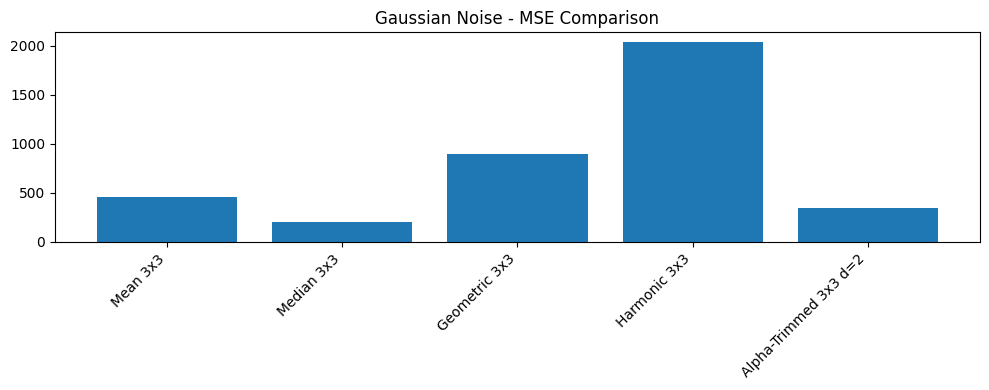

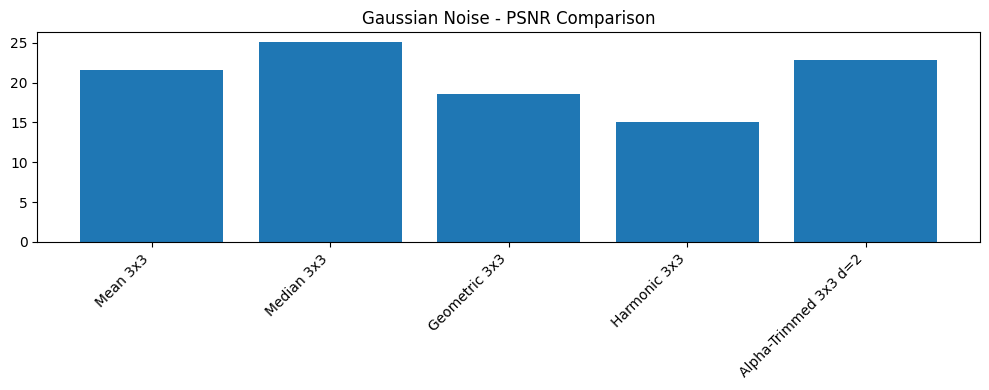

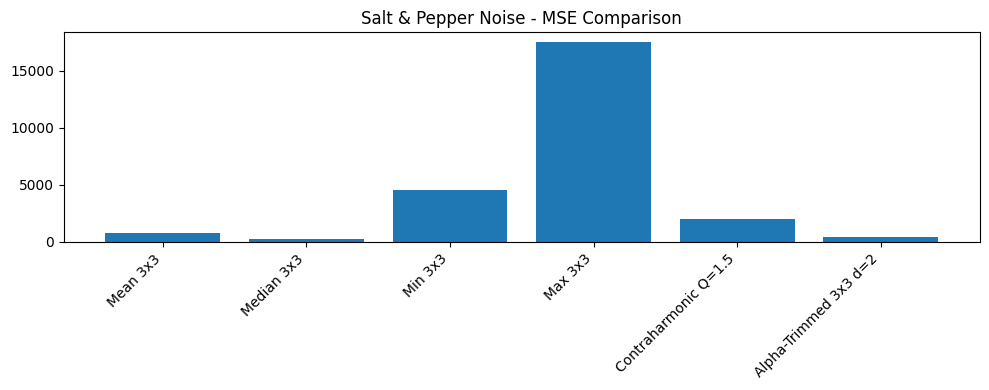

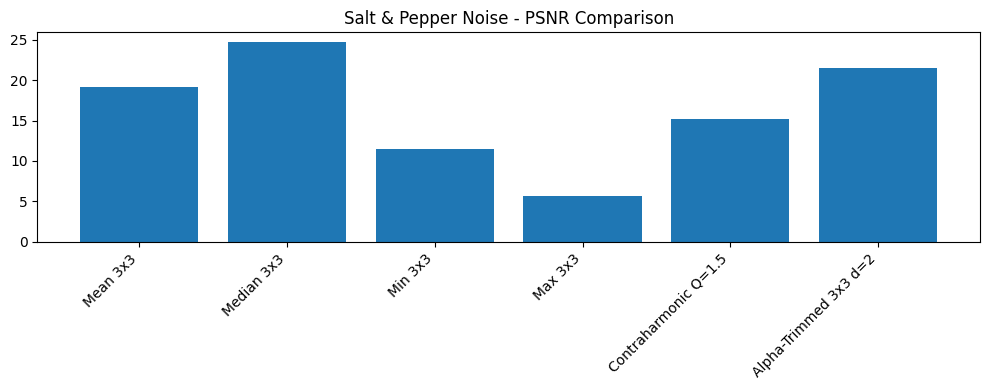

In [ ]:
def plot_scores(scores, title_prefix=""):
    names = [s[0] for s in scores]
    mses = [s[1] for s in scores]
    psnrs = [s[2] for s in scores]

    plt.figure(figsize=(10, 4))
    plt.bar(names, mses)
    plt.title(f"{title_prefix}MSE Comparison")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.bar(names, psnrs)
    plt.title(f"{title_prefix}PSNR Comparison")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_scores(gaussian_scores, title_prefix="Gaussian Noise - ")
plot_scores(sp_scores, title_prefix="Salt & Pepper Noise - ")

# 6. Summary of Practical Insights

## Noise vs best filter tendencies

### Gaussian noise
Usually best handled by:
- arithmetic mean
- Gaussian smoothing
- geometric or alpha-trimmed variants in some conditions

### Salt-and-pepper noise
Usually best handled by:
- median filter
- contraharmonic filter if impulse polarity is known
- alpha-trimmed mean for mixed conditions

### Uniform noise
Often handled reasonably by:
- averaging filters
- midpoint filter

### Salt-only noise
- min filter may help
- contraharmonic with \(Q<0\) can be effective

### Pepper-only noise
- max filter may help
- contraharmonic with \(Q>0\) can be effective

## Main conceptual takeaway
There is no universally best filter.  
The correct restoration method depends on:
- the statistical noise model
- whether the corruption is additive or impulsive
- whether edge preservation is critical
- whether the noise is symmetric, skewed, bounded, or sparse